In [2]:
import pyeo.classification
import numpy as np
import matplotlib.pyplot as plt

print("✅ All imports working!")
print("Ready to build the uncertainty layer.")

✅ All imports working!
Ready to build the uncertainty layer.


In [3]:
import numpy as np
from osgeo import gdal
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

gdal.UseExceptions()

In [4]:
def compute_uncertainty(prob_raster_path: str, out_path: str) -> np.ndarray:
    """
    Reads a per-class probability raster produced by PyEO's classify_image()
    and computes per-pixel uncertainty using two complementary metrics:

    1. Margin uncertainty  : 1 - (top_class_prob - second_class_prob)
       High when the top two classes are very close in probability.

    2. Entropy             : -sum(p * log(p)) normalised to [0,1]
       High when probability is spread evenly across all classes.

    Both are saved as separate bands in a single GeoTIFF output.

    Parameters
    ----------
    prob_raster_path : str
        Path to the multi-band probability .tif from classify_image()
    out_path : str
        Path to save the output uncertainty raster (2 bands)

    Returns
    -------
    uncertainty : np.ndarray
        Array of shape (2, height, width) — [margin, entropy]
    """
    ds = gdal.Open(prob_raster_path)
    n_bands = ds.RasterCount
    width = ds.RasterXSize
    height = ds.RasterYSize

    # Read all probability bands into array of shape (n_classes, height, width)
    probs = np.stack(
        [ds.GetRasterBand(i + 1).ReadAsArray() for i in range(n_bands)],
        axis=0
    ).astype(np.float32)

    # Mask nodata pixels (where all bands are 0)
    nodata_mask = np.all(probs == 0, axis=0)

    # --- Metric 1: Margin uncertainty ---
    sorted_probs = np.sort(probs, axis=0)[::-1]  # descending per pixel
    margin = 1.0 - (sorted_probs[0] - sorted_probs[1])
    margin[nodata_mask] = 0.0

    # --- Metric 2: Normalised Shannon entropy ---
    epsilon = 1e-10  # avoid log(0)
    log_probs = np.log(probs + epsilon)
    entropy = -np.sum(probs * log_probs, axis=0)
    max_entropy = np.log(n_bands)  # maximum possible entropy for normalisation
    entropy = entropy / max_entropy
    entropy[nodata_mask] = 0.0

    uncertainty = np.stack([margin, entropy], axis=0)

    # Write output raster with same projection/geotransform as input
    driver = gdal.GetDriverByName("GTiff")
    out_ds = driver.Create(out_path, width, height, 2, gdal.GDT_Float32)
    out_ds.SetGeoTransform(ds.GetGeoTransform())
    out_ds.SetProjection(ds.GetProjection())

    out_ds.GetRasterBand(1).WriteArray(uncertainty[0])
    out_ds.GetRasterBand(1).SetDescription("Margin Uncertainty")

    out_ds.GetRasterBand(2).WriteArray(uncertainty[1])
    out_ds.GetRasterBand(2).SetDescription("Entropy Uncertainty")

    out_ds.FlushCache()
    out_ds = None
    ds = None

    print(f"Uncertainty raster saved to: {out_path}")
    return uncertainty

In [5]:
def plot_uncertainty(uncertainty: np.ndarray, out_path: str = None):
    """
    Plots margin and entropy uncertainty side by side.

    Parameters
    ----------
    uncertainty : np.ndarray
        Array of shape (2, height, width) as returned by compute_uncertainty()
    out_path : str, optional
        If provided, saves the figure to this path
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    titles = ["Margin Uncertainty", "Normalised Entropy"]
    for i, ax in enumerate(axes):
        band = uncertainty[i]
        # mask nodata
        masked = np.ma.masked_where(band == 0, band)
        im = ax.imshow(masked, cmap="RdYlGn_r", vmin=0, vmax=1)
        ax.set_title(titles[i], fontsize=13)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Uncertainty (0=confident, 1=uncertain)")

    plt.suptitle("PyEO Classification Uncertainty Map", fontsize=15, fontweight="bold")
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"Figure saved to: {out_path}")
    plt.show()

In [8]:
def add_uncertainty_to_pipeline(
    prob_out_path: str,
    class_out_path: str,
    uncertainty_out_path: str,
    high_uncertainty_threshold: float = 0.7
) -> dict:
    """
    Sits on top of PyEO's classify_image() output and produces:

    1. An uncertainty raster (margin + entropy bands)
    2. A filtered alert raster — change detections with high uncertainty flagged as 0
    3. A summary report dict with key statistics

    This is designed to be called immediately after classify_image() in the pipeline.

    Parameters
    ----------
    prob_out_path : str
        Path to probability raster from classify_image()
    class_out_path : str
        Path to classification raster from classify_image()
    uncertainty_out_path : str
        Path to save the uncertainty raster
    high_uncertainty_threshold : float
        Margin uncertainty above this value will be flagged. Default 0.7

    Returns
    -------
    report : dict
        Summary statistics about classification confidence
    """

    # Compute uncertainty
    uncertainty = compute_uncertainty(prob_out_path, uncertainty_out_path)
    margin     = uncertainty[0]
    entropy    = uncertainty[1]

    # Read the classification map
    ds = gdal.Open(class_out_path)
    class_array = ds.GetRasterBand(1).ReadAsArray().astype(np.float32)
    ds = None

    # Valid pixels only (nodata = 0)
    valid_mask = class_array > 0

    # Flag pixels where model was uncertain
    high_uncertainty_mask = (margin > high_uncertainty_threshold) & valid_mask

    # Build filtered classification — uncertain pixels set to nodata
    filtered_class = class_array.copy()
    filtered_class[high_uncertainty_mask] = 0

    # Save filtered classification alongside originals
    filtered_path = class_out_path.replace(".tif", "_uncertainty_filtered.tif")
    src_ds = gdal.Open(class_out_path)
    driver = gdal.GetDriverByName("GTiff")
    out_ds = driver.Create(
        filtered_path,
        src_ds.RasterXSize,
        src_ds.RasterYSize,
        1,
        gdal.GDT_Byte
    )
    out_ds.SetGeoTransform(src_ds.GetGeoTransform())
    out_ds.SetProjection(src_ds.GetProjection())
    out_ds.GetRasterBand(1).WriteArray(filtered_class.astype(np.uint8))
    out_ds.FlushCache()
    out_ds = None
    src_ds = None

    # Summary report
    n_valid        = int(np.sum(valid_mask))
    n_uncertain    = int(np.sum(high_uncertainty_mask))
    pct_uncertain  = (n_uncertain / n_valid * 100) if n_valid > 0 else 0

    report = {
        "total_valid_pixels"       : n_valid,
        "high_uncertainty_pixels"  : n_uncertain,
        "pct_high_uncertainty"     : round(pct_uncertain, 2),
        "mean_margin_uncertainty"  : round(float(margin[valid_mask].mean()), 4),
        "mean_entropy"             : round(float(entropy[valid_mask].mean()), 4),
        "filtered_class_path"      : filtered_path,
        "uncertainty_raster_path"  : uncertainty_out_path,
        "threshold_used"           : high_uncertainty_threshold
    }

    return report

In [5]:
import sys
sys.path.insert(0, os.path.dirname(os.path.abspath("uncertainty_layer.ipynb")))

from uncertainty import compute_uncertainty, add_uncertainty_to_pipeline, plot_uncertainty

print("uncertainty.py module imported successfully")

uncertainty.py module imported successfully


In [23]:
from pyeo.classification import classify_image

image_path = "/home/m/mp730/Documents/pyeo/models/my_model/composite_T36MYE_20230220T074941_clipped.tif"
model_path = "/home/m/mp730/Documents/pyeo/models/my_model/my_model.pkl"
class_out_path = "/home/m/mp730/Documents/pyeo/models/my_model/composite_T36MYE_20230220T074941_clipped_full_class_testing.tif"
prob_out_path = "/home/m/mp730/Documents/pyeo/models/my_model/composite_T36MYE_20230220T074941_clipped_full_class_testing_proba.tif"

classify_image(image_path=image_path, model_path=model_path, class_out_path=class_out_path, prob_out_path=prob_out_path)

2026-04-24 16:07:39,947: INFO: Classifying file: /home/m/mp730/Documents/pyeo/models/my_model/composite_T36MYE_20230220T074941_clipped.tif
2026-04-24 16:07:39,948: INFO: Saved model     : /home/m/mp730/Documents/pyeo/models/my_model/my_model.pkl
/home/m/mp730/miniconda3/envs/pyeo_env/lib/python3.10/site-packages/sklearn/base.py:347: InconsistentVersionWarning: Trying to unpickle estimator ExtraTreeClassifier from version 1.5.2 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/m/mp730/miniconda3/envs/pyeo_env/lib/python3.10/site-packages/sklearn/base.py:347: InconsistentVersionWarning: Trying to unpickle estimator ExtraTreesClassifier from version 1.5.2 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://sc

('/home/m/mp730/Documents/pyeo/models/my_model/composite_T36MYE_20230220T074941_clipped_full_class_testing.tif',
 '/home/m/mp730/Documents/pyeo/models/my_model/composite_T36MYE_20230220T074941_clipped_full_class_testing_proba.tif')

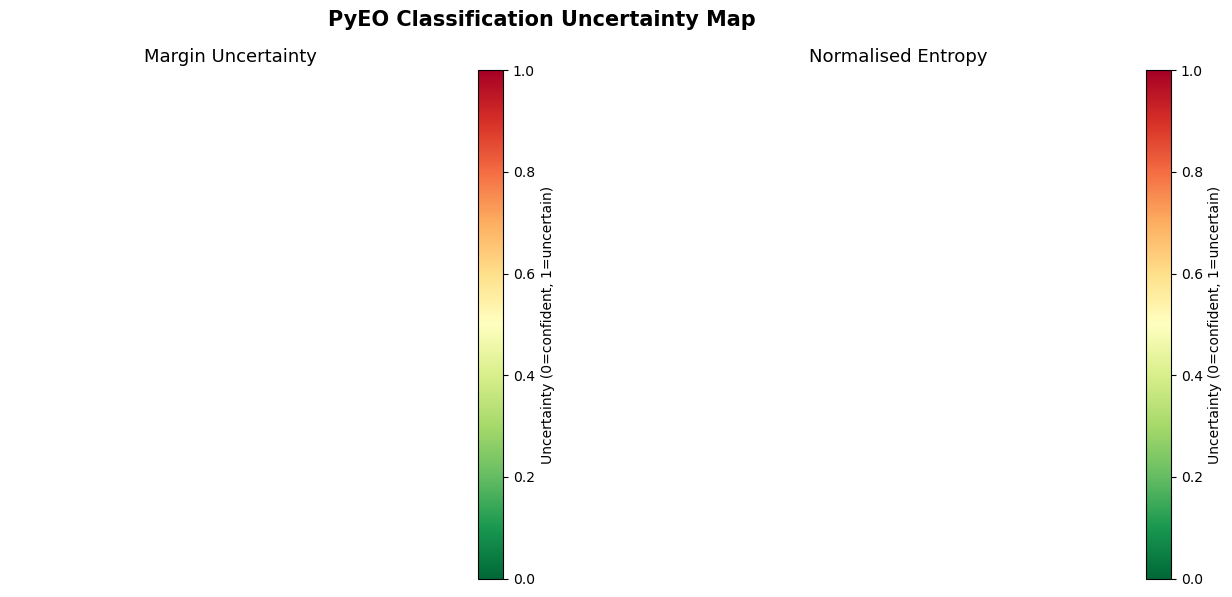

In [24]:
uncertainty_array = compute_uncertainty(prob_raster_path="/home/m/mp730/Documents/pyeo/models/my_model/composite_T36MYE_20230220T074941_clipped_full_class_testing_proba.tif", out_path="/home/m/mp730/Documents/pyeo/models/my_model/composite_T36MYE_20230220T074941_clipped_full_class_testing_uncertainty.tif")

plot_uncertainty(uncertainty_array)